# Task 1: Financial Data Analysis - 10-K Report Analysis
## BCG GenAI Consulting: Global Finance Corp Financial Analysis

This notebook analyzes extracted 10-K financial data from Microsoft, Tesla, and Apple for the last three fiscal years.
**Focus Metrics:** Total Revenue, Net Income, Total Assets, Total Liabilities, Operating Cash Flow

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Extracted Financial Data

In [8]:
# Load the extracted financial data
df = pd.read_csv('../data/financial_data_raw.csv')

# Convert Fiscal Year to datetime
df['Fiscal Year'] = pd.to_datetime(df['Fiscal Year'])

print("Extracted financial data shape:", df.shape)
print("\nFirst few rows:")
df.head(10)

Extracted financial data shape: (6, 27)

First few rows:


,Company,Ticker,Company Name,CIK,Industry,Business Category,State of Incorporation,Phone,Address,Fiscal Year,...,Current Assets,Long-term Assets,Total Liabilities,Current Liabilities,Long-term Liabilities,Long-term Debt,Stockholders Equity,Operating Cash Flow,Investing Cash Flow,Financing Cash Flow
0,Microsoft,MSFT,MICROSOFT CORP,789019,Services-Prepackaged Software,Operating Company,NaN,NaN,"ONE MICROSOFT WAY\nREDMOND, WA 98052-6399",2025-06-30,...,1.911310e+11,4.056500e+10,2.755240e+11,1.412180e+11,4.518600e+10,4.015200e+10,3.434790e+11,1.361620e+11,-7.259900e+10,-5.169900e+10
1,Microsoft,MSFT,MICROSOFT CORP,789019,Services-Prepackaged Software,Operating Company,NaN,NaN,"ONE MICROSOFT WAY\nREDMOND, WA 98052-6399",2024-06-30,...,1.597340e+11,3.646000e+10,2.436860e+11,1.252860e+11,2.706400e+10,4.268800e+10,2.684770e+11,1.185480e+11,-9.697000e+10,-3.775700e+10
2,Microsoft,MSFT,MICROSOFT CORP,789019,Services-Prepackaged Software,Operating Company,NaN,NaN,"ONE MICROSOFT WAY\nREDMOND, WA 98052-6399",2023-06-30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.758200e+10,-2.268000e+10,-4.393500e+10
3,Apple,AAPL,Apple Inc.,320193,Electronic Computers,Operating Company,NaN,NaN,"ONE APPLE PARK WAY\nCUPERTINO, CA 95014",2025-09-27,...,1.479570e+11,2.112840e+11,2.855080e+11,1.656310e+11,1.198770e+11,7.832800e+10,7.373300e+10,1.114820e+11,1.519500e+10,-1.206860e+11
4,Apple,AAPL,Apple Inc.,320193,Electronic Computers,Operating Company,NaN,NaN,"ONE APPLE PARK WAY\nCUPERTINO, CA 95014",2024-09-28,...,1.529870e+11,2.119930e+11,3.080300e+11,1.763920e+11,1.316380e+11,8.575000e+10,5.695000e+10,1.182540e+11,2.935000e+09,-1.219830e+11
5,Apple,AAPL,Apple Inc.,320193,Electronic Computers,Operating Company,NaN,NaN,"ONE APPLE PARK WAY\nCUPERTINO, CA 95014",2023-09-30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.105430e+11,3.705000e+09,-1.084880e+11


## Methodology (summary)

- **Data source**: financial statements from SEC EDGAR **10-K** filings, extracted via a Python script (edgartools) and loaded from `data/financial_data_raw.csv`.
- **Scope**: 2 companies in the current dataset (**Microsoft, Apple**) across the **last 3 available fiscal years**.
- **Extracted metrics**: Total Revenue, Net Income, Total Assets, Total Liabilities, Operating Cash Flow.
- **Analysis steps**:
  - basic data validation (missing values, types)
  - “latest year” comparison by metric
  - trends (Revenue, Net Profit Margin)
  - financial health ratios (leverage, efficiency, cash coverage)

Goal: identify trends (growth, profitability, capital structure) and translate them into business-relevant insights.

## 3. Data Overview and Quality Check

In [ ]:
# Data quality check
print("Data info:")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nTickers: {df['Ticker'].unique()}")
print("Number of records per ticker:")
print(df['Ticker'].value_counts().sort_index())

print("\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

print("\nData summary (in billions):")
summary_cols = ['Total Revenue', 'Net Income', 'Total Assets', 'Total Liabilities', 'Operating Cash Flow']
(df[summary_cols] / 1e9).describe().round(2)

📋 Data Info:
Total rows: 6
Total columns: 8

Companies: ['MSFT' 'AAPL']
Number of records per company:
Ticker
AAPL    3
MSFT    3
Name: count, dtype: int64

🔍 Missing Values:
Total Assets         2
Total Liabilities    2
dtype: int64

💰 Data Summary (in billions):


,Total Revenue,Net Income,Total Assets,Total Liabilities,Operating Cash Flow
count,6.00,6.00,4.00,4.00,6.00
mean,321.54,94.18,463.85,278.19,113.76
std,86.07,13.40,125.33,26.72,15.78
min,211.92,72.36,359.24,243.69,87.58
25%,254.27,89.54,363.55,267.56,110.78
50%,332.50,95.37,438.57,280.52,114.87
75%,389.10,100.62,538.87,291.14,118.47
max,416.16,112.01,619.00,308.03,136.16


## Data quality and limitations

- The dataset contains **6 rows** (3 years × 2 companies).
- **Missing values**: `Total Assets` and `Total Liabilities` are missing for some years.
  - Impact: several balance-sheet ratios (Debt-to-Equity, Debt-to-Assets, ROA, Asset Turnover) are computed **only for the most recent year with a complete balance sheet**.
- **Tesla** is not present in the current CSV output (no TSLA rows).

Takeaway: trend conclusions for Revenue, Net Income, and Operating Cash Flow are still meaningful for MSFT/AAPL, but balance-sheet-based conclusions should be interpreted with this completeness constraint in mind.

## 4. Year-over-Year Growth Analysis

In [6]:
# Calculate YoY growth for each company and metric across all years
yoy_growth_all = []

for ticker in sorted(df['Ticker'].unique()):
    company_data = df[df['Ticker'] == ticker].sort_values('Fiscal Year')
    company_name = company_data['Company'].iloc[0]
    
    for _, row in company_data.iterrows():
        fiscal_year = row['Fiscal Year'].strftime('%Y-%m-%d')
        
        # Get previous year data if it exists
        prev_data = company_data[company_data['Fiscal Year'] < row['Fiscal Year']]
        
        if len(prev_data) > 0:
            prev_row = prev_data.iloc[-1]
            
            # Calculate YoY growth for each metric
            revenue_growth = None
            if pd.notna(row['Total Revenue']) and pd.notna(prev_row['Total Revenue']) and prev_row['Total Revenue'] != 0:
                revenue_growth = ((row['Total Revenue'] - prev_row['Total Revenue']) / prev_row['Total Revenue'] * 100)
            
            income_growth = None
            if pd.notna(row['Net Income']) and pd.notna(prev_row['Net Income']) and prev_row['Net Income'] != 0:
                income_growth = ((row['Net Income'] - prev_row['Net Income']) / prev_row['Net Income'] * 100)
            
            assets_growth = None
            if pd.notna(row['Total Assets']) and pd.notna(prev_row['Total Assets']) and prev_row['Total Assets'] != 0:
                assets_growth = ((row['Total Assets'] - prev_row['Total Assets']) / prev_row['Total Assets'] * 100)
            
            liabilities_growth = None
            if pd.notna(row['Total Liabilities']) and pd.notna(prev_row['Total Liabilities']) and prev_row['Total Liabilities'] != 0:
                liabilities_growth = ((row['Total Liabilities'] - prev_row['Total Liabilities']) / prev_row['Total Liabilities'] * 100)
            
            ocf_growth = None
            if pd.notna(row['Operating Cash Flow']) and pd.notna(prev_row['Operating Cash Flow']) and prev_row['Operating Cash Flow'] != 0:
                ocf_growth = ((row['Operating Cash Flow'] - prev_row['Operating Cash Flow']) / prev_row['Operating Cash Flow'] * 100)
        else:
            # First year has no previous year, so all growth values are None
            revenue_growth = None
            income_growth = None
            assets_growth = None
            liabilities_growth = None
            ocf_growth = None
        
        yoy_growth_all.append({
            'Company': company_name,
            'Fiscal Year': fiscal_year,
            'Revenue YoY %': revenue_growth,
            'Net Income YoY %': income_growth,
            'Total Assets YoY %': assets_growth,
            'Total Liabilities YoY %': liabilities_growth,
            'Operating Cash Flow YoY %': ocf_growth,
        })

yoy_df = pd.DataFrame(yoy_growth_all)

# Round for better display
yoy_display = yoy_df.copy()
for col in ['Revenue YoY %', 'Net Income YoY %', 'Total Assets YoY %', 'Total Liabilities YoY %', 'Operating Cash Flow YoY %']:
    yoy_display[col] = yoy_display[col].round(2)

yoy_display

,Company,Fiscal Year,Revenue YoY %,Net Income YoY %,Total Assets YoY %,Total Liabilities YoY %,Operating Cash Flow YoY %
0,Apple,2023-09-30,NaN,NaN,NaN,NaN,NaN
1,Apple,2024-09-28,2.02,-3.36,NaN,NaN,6.98
2,Apple,2025-09-27,6.43,19.50,-1.57,-7.31,-5.73
3,Microsoft,2023-06-30,NaN,NaN,NaN,NaN,NaN
4,Microsoft,2024-06-30,15.67,21.80,NaN,NaN,35.36
5,Microsoft,2025-06-30,14.93,15.54,20.86,13.07,14.86


## 5. Comparative Analysis by Metric

In [9]:
# Comparative metrics analysis
metrics = ['Total Revenue', 'Net Income', 'Total Assets', 'Total Liabilities', 'Operating Cash Flow']

comparison_data = []
for ticker in df['Ticker'].unique():
    company_data = df[df['Ticker'] == ticker].sort_values('Fiscal Year')
    if len(company_data) > 0:
        latest = company_data.iloc[-1]
        company_name = company_data['Company'].iloc[0]
        
        for metric in metrics:
            if pd.notna(latest[metric]):
                comparison_data.append({
                    'Company': company_name,
                    'Metric': metric,
                    'Latest Value ($B)': latest[metric] / 1e9,
                    'Fiscal Year': latest['Fiscal Year'].strftime('%Y-%m-%d')
                })

comparison_df = pd.DataFrame(comparison_data)
print("Latest Financial Metrics (Most Recent Fiscal Year):\n")
for metric in metrics:
    print(f"\n{metric}:")
    metric_data = comparison_df[comparison_df['Metric'] == metric].sort_values('Latest Value ($B)', ascending=False)
    for _, row in metric_data.iterrows():
        print(f"  {row['Company']}: ${row['Latest Value ($B)']:.2f}B (as of {row['Fiscal Year']})")

Latest Financial Metrics (Most Recent Fiscal Year):


Total Revenue:
  Apple: $416.16B (as of 2025-09-27)
  Microsoft: $281.72B (as of 2025-06-30)

Net Income:
  Apple: $112.01B (as of 2025-09-27)
  Microsoft: $101.83B (as of 2025-06-30)

Total Assets:
  Microsoft: $619.00B (as of 2025-06-30)
  Apple: $359.24B (as of 2025-09-27)

Total Liabilities:
  Apple: $285.51B (as of 2025-09-27)
  Microsoft: $275.52B (as of 2025-06-30)

Operating Cash Flow:
  Microsoft: $136.16B (as of 2025-06-30)
  Apple: $111.48B (as of 2025-09-27)


## 6. Revenue Trend Analysis

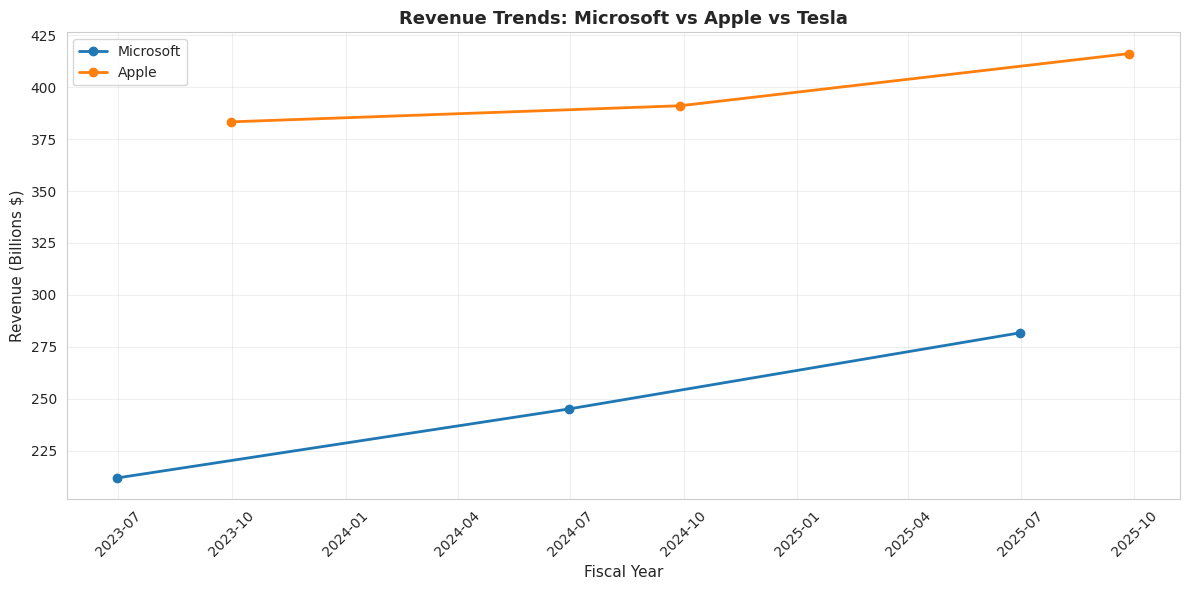

📊 Revenue Trend Summary:

Apple (AAPL):
  Revenue range: $383.29B - $416.16B

Microsoft (MSFT):
  Revenue range: $211.91B - $281.72B


In [ ]:
# Revenue trend analysis and visualization
fig, ax = plt.subplots(figsize=(12, 6))

for ticker in df['Ticker'].unique():
    company_data = df[df['Ticker'] == ticker].sort_values('Fiscal Year').dropna(subset=['Total Revenue'])
    if len(company_data) > 0:
        company_name = company_data['Company'].iloc[0]
        revenue_billions = company_data['Total Revenue'] / 1e9
        ax.plot(company_data['Fiscal Year'], revenue_billions, marker='o', label=company_name, linewidth=2)

ax.set_xlabel('Fiscal Year', fontsize=11)
ax.set_ylabel('Revenue (Billions $)', fontsize=11)
ax.set_title('Revenue Trends: Microsoft vs Apple vs Tesla', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Revenue trend summary:")
for ticker in sorted(df['Ticker'].unique()):
    company_data = df[df['Ticker'] == ticker].sort_values('Fiscal Year').dropna(subset=['Total Revenue'])
    if len(company_data) > 0:
        company_name = company_data['Company'].iloc[0]
        revenues = company_data['Total Revenue'].values / 1e9
        print(f"\n{company_name} ({ticker}):")
        print(f"  Revenue range: ${revenues.min():.2f}B - ${revenues.max():.2f}B")

## Interpreting revenue trends

Key point: Apple remains larger in revenue, while Microsoft shows faster growth over the observed period.

- In the latest fiscal year shown, **Apple** reports about **$416.16B** revenue vs **Microsoft** at about **$281.72B**.
- Microsoft’s line is steeper, consistent with the “growth leaders” output where Microsoft shows higher revenue YoY growth (about **+14.93%**) than Apple (about **+6.43%**) for the period measured.

Business interpretation:
- Apple: very large revenue base with steadier growth.
- Microsoft: stronger recent expansion, suggesting faster scaling of key businesses.

## 7. Profitability Analysis: Net Income vs Revenue

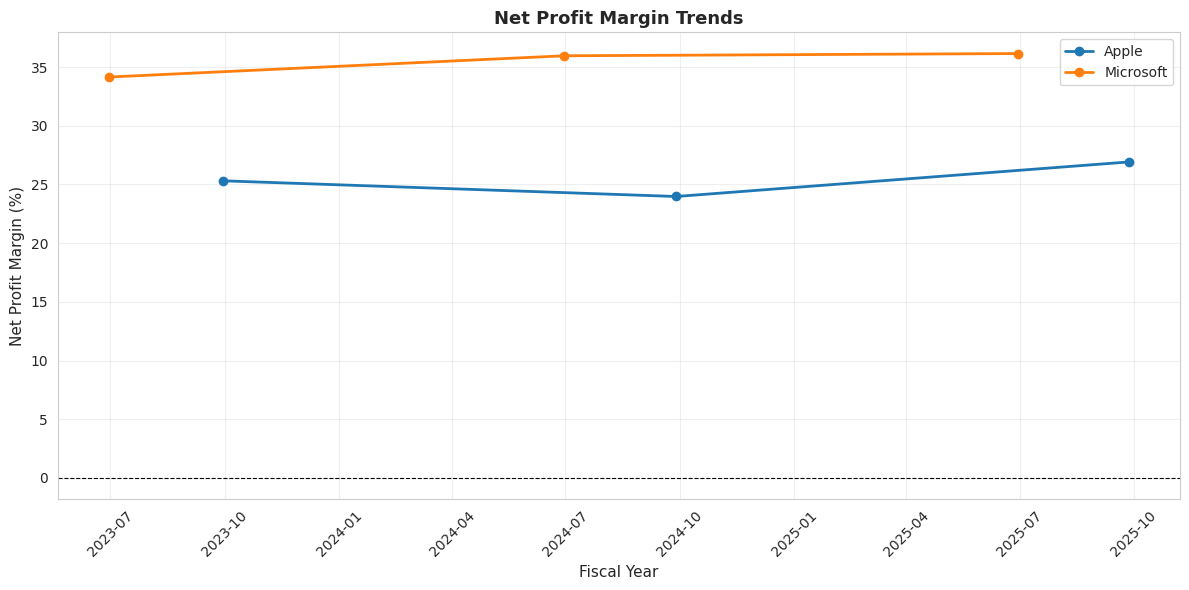

📊 Profit Margin Summary:


,Company,Fiscal Year,Profit Margin %
0,Microsoft,2023-06-30,34.146238
1,Microsoft,2024-06-30,35.955973
2,Microsoft,2025-06-30,36.146015
3,Apple,2023-09-30,25.306234
4,Apple,2024-09-28,23.971256
5,Apple,2025-09-27,26.915064


In [ ]:
# Calculate profit margin for each company
profit_data = []

for ticker in df['Ticker'].unique():
    company_data = df[df['Ticker'] == ticker].sort_values('Fiscal Year')
    company_name = company_data['Company'].iloc[0]
    
    for _, row in company_data.iterrows():
        if pd.notna(row['Total Revenue']) and pd.notna(row['Net Income']):
            profit_margin = (row['Net Income'] / row['Total Revenue']) * 100
            profit_data.append({
                'Company': company_name,
                'Fiscal Year': row['Fiscal Year'],
                'Profit Margin %': profit_margin,
            })

profit_df = pd.DataFrame(profit_data)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

for ticker in sorted(df['Ticker'].unique()):
    company_name = df[df['Ticker'] == ticker]['Company'].iloc[0]
    company_profit = profit_df[profit_df['Company'] == company_name].sort_values('Fiscal Year')
    if len(company_profit) > 0:
        ax.plot(company_profit['Fiscal Year'], company_profit['Profit Margin %'], 
                marker='o', label=company_name, linewidth=2)

ax.set_xlabel('Fiscal Year', fontsize=11)
ax.set_ylabel('Net Profit Margin (%)', fontsize=11)
ax.set_title('Net Profit Margin Trends', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Profit margin summary:")
profit_df

## Profitability (net profit margin) — observations

- **Microsoft** shows a higher and relatively stable net margin (roughly **34–36%**), with the latest value around **36.15%**.
- **Apple** is lower (roughly **24–27%**), with the latest value around **26.92%**.

Interpretation:
- A higher net margin indicates stronger ability to convert revenue into net profit (pricing power, cost structure, product/service mix).
- Apple remains highly profitable, but the gap suggests Microsoft has had a more favorable margin profile in the years observed.

Note: pairing strong growth with strong margins is typically a positive signal for cash generation and reinvestment capacity.

## 8. Financial Ratios and Health Metrics

In [ ]:
# Calculate key financial ratios
ratios_data = []

for ticker in df['Ticker'].unique():
    company_data = df[df['Ticker'] == ticker].sort_values('Fiscal Year')
    company_name = company_data['Company'].iloc[0]
    
    # Use most recent year with complete data
    latest_complete = company_data.dropna(subset=['Total Assets', 'Total Liabilities']).iloc[-1] if len(company_data.dropna(subset=['Total Assets', 'Total Liabilities'])) > 0 else None
    
    if latest_complete is not None:
        assets = latest_complete['Total Assets']
        liabilities = latest_complete['Total Liabilities']
        equity = assets - liabilities
        revenue = latest_complete['Total Revenue']
        ocf = latest_complete['Operating Cash Flow']
        
        # Calculate ratios
        debt_to_equity = liabilities / equity if equity > 0 else np.nan
        debt_to_assets = liabilities / assets if assets > 0 else np.nan
        roa = (latest_complete['Net Income'] / assets * 100) if assets > 0 else np.nan
        asset_turnover = (revenue / assets) if assets > 0 else np.nan
        ocf_ratio = (ocf / liabilities) if pd.notna(ocf) and liabilities > 0 else np.nan
        
        ratios_data.append({
            'Company': company_name,
            'Debt-to-Equity': debt_to_equity,
            'Debt-to-Assets': debt_to_assets,
            'ROA (%)': roa,
            'Asset Turnover': asset_turnover,
            'OCF-to-Liabilities': ocf_ratio,
        })

ratios_df = pd.DataFrame(ratios_data)

print("Financial health ratios (based on most recent complete year):\n")
ratios_df


💹 Financial Health Ratios (Based on Most Recent Complete Year):



,Company,Debt-to-Equity,Debt-to-Assets,ROA (%),Asset Turnover,OCF-to-Liabilities
0,Microsoft,0.802157,0.445109,16.450970,0.455125,0.494193
1,Apple,3.872187,0.794753,31.179626,1.158445,0.390469


## Financial ratios — interpretation

Ratios are computed using the **most recent year with a complete balance sheet**.

### Capital structure (leverage)
- **Debt-to-Equity**: Microsoft ≈ **0.80** (more conservative), Apple ≈ **3.87** (high leverage).
- **Debt-to-Assets**: Microsoft ≈ **0.45**, Apple ≈ **0.79**.

### Efficiency and returns
- **ROA**: Apple ≈ **31.18%** vs Microsoft ≈ **16.45%** (higher profit per dollar of assets).
- **Asset Turnover**: Apple ≈ **1.16** vs Microsoft ≈ **0.46** (higher revenue per dollar of assets).

### Operating cash coverage
- **OCF-to-Liabilities**: Microsoft ≈ **0.49** vs Apple ≈ **0.39** (stronger operating cash coverage of liabilities).

Overall read:
- Microsoft: lower leverage and strong operating cash generation.
- Apple: very strong efficiency/returns, but a more leveraged capital structure.

## 9. Key Findings and Business Insights

In [ ]:
# Generate comprehensive summary and insights
print("=" * 80)
print("KEY FINDINGS & INSIGHTS - 10-K FINANCIAL ANALYSIS")
print("=" * 80)

# Revenue Rankings
print("\nREVENUE RANKINGS (Latest Year):")
revenue_ranking = df.dropna(subset=['Total Revenue']).sort_values('Fiscal Year').drop_duplicates('Ticker', keep='last').sort_values('Total Revenue', ascending=False)
for i, (_, row) in enumerate(revenue_ranking.iterrows(), 1):
    print(f"  {i}. {row['Company']}: ${row['Total Revenue']/1e9:.2f}B")

# Growth Leaders
print("\nGROWTH LEADERS (YoY Revenue Growth):")
if len(yoy_df) > 0:
    for _, row in yoy_df.sort_values('Revenue YoY %', ascending=False, na_position='last').iterrows():
        growth_val = row['Revenue YoY %']
        if pd.notna(growth_val):
            print(f"  {row['Company']}: {growth_val:+.2f}%")

# Profitability Leaders
print("\nPROFITABILITY LEADERS (Net Profit Margin):")
profit_latest = profit_df.sort_values('Fiscal Year').drop_duplicates('Company', keep='last').sort_values('Profit Margin %', ascending=False)
for _, row in profit_latest.iterrows():
    print(f"  {row['Company']}: {row['Profit Margin %']:.2f}%")

# Financial Health
print("\nFINANCIAL HEALTH (Debt-to-Equity Ratio):")
dte_sorted = ratios_df.sort_values('Debt-to-Equity')
for _, row in dte_sorted.iterrows():
    if pd.notna(row['Debt-to-Equity']):
        status = "Conservative" if row['Debt-to-Equity'] < 1 else "Leveraged" if row['Debt-to-Equity'] < 2 else "Highly leveraged"
        print(f"  {row['Company']}: {row['Debt-to-Equity']:.2f} ({status})")

# Cash Flow Strength
print("\nOPERATING CASH FLOW (Latest Year):")
ocf_data = df.dropna(subset=['Operating Cash Flow']).sort_values('Fiscal Year').drop_duplicates('Ticker', keep='last').sort_values('Operating Cash Flow', ascending=False)
for _, row in ocf_data.iterrows():
    print(f"  {row['Company']}: ${row['Operating Cash Flow']/1e9:.2f}B")

print("\n" + "=" * 80)
print("Analysis complete - data ready for downstream use")
print("=" * 80)


KEY FINDINGS & INSIGHTS - 10-K FINANCIAL ANALYSIS

🏆 REVENUE RANKINGS (Latest Year):
  1. Apple: $416.16B
  2. Microsoft: $281.72B

📈 GROWTH LEADERS (YoY Revenue Growth):
  ↑ Microsoft: +14.93%
  ↑ Apple: +6.43%

💰 PROFITABILITY LEADERS (Net Profit Margin):
  Microsoft: 36.15%
  Apple: 26.92%

🏦 FINANCIAL HEALTH (Debt-to-Equity Ratio):
  Microsoft: 0.80 ✓ Conservative
  Apple: 3.87 ⚠⚠ Highly Leveraged

💵 OPERATING CASH FLOW (Latest Year):
  Microsoft: $136.16B
  Apple: $111.48B

✅ Analysis Complete - Data Ready for Financial Chatbot Integration


## Final summary (findings and conclusions)

### 1) Scale vs growth
- **Apple** leads on **revenue scale** in the latest year, while **Microsoft** leads on **revenue growth** over the observed period.

### 2) Profitability
- **Microsoft** is the **net margin leader** (about 36% in the latest year), indicating very strong conversion of revenue into net profit.
- **Apple** remains highly profitable, but below Microsoft on net margin in this dataset.

### 3) Balance-sheet health
- **Microsoft**: moderate leverage (D/E ≈ 0.80) which typically implies higher financial flexibility.
- **Apple**: high leverage (D/E ≈ 3.87), suggesting heavier reliance on its debt/equity structure.

### 4) Cash generation
- Both companies generate strong **Operating Cash Flow**; Microsoft shows slightly stronger liability coverage via OCF (OCF/Liabilities).

### Limitations and next steps
- The current outputs do not include **Tesla**.
- Missing balance-sheet values for some years limit multi-year ratio consistency.

Conclusion: Apple is larger in revenue and very efficient in asset usage, while Microsoft combines faster growth, higher margins, and more conservative leverage—an overall very strong profile for funding investment and absorbing shocks.

In [ ]:
# Save all analysis results to CSV files
import os

# Create results directory if it doesn't exist
results_dir = '../data/analysis'
os.makedirs(results_dir, exist_ok=True)

# 1. Save Year-over-Year Growth Analysis
yoy_export = yoy_df.copy()
yoy_export.to_csv(f'{results_dir}/yoy_growth_analysis.csv', index=False)
print(f"✓ Saved YoY Growth Analysis: {results_dir}/yoy_growth_analysis.csv")

# 2. Save Profit Margin Analysis
profit_export = profit_df.copy()
profit_export.to_csv(f'{results_dir}/profit_margin_analysis.csv', index=False)
print(f"✓ Saved Profit Margin Analysis: {results_dir}/profit_margin_analysis.csv")

# 3. Save Financial Ratios Analysis
ratios_export = ratios_df.copy()
ratios_export.to_csv(f'{results_dir}/financial_ratios_analysis.csv', index=False)
print(f"✓ Saved Financial Ratios Analysis: {results_dir}/financial_ratios_analysis.csv")


# 5. Save Raw Financial Data Summary (latest year)
latest_data = df.sort_values('Fiscal Year', ascending=False).groupby('Company').first().reset_index()
latest_data.to_csv(f'{results_dir}/latest_financial_data_summary.csv', index=False)
print(f"✓ Saved Latest Financial Data Summary: {results_dir}/latest_financial_data_summary.csv")



✓ Saved YoY Growth Analysis: ../data/analysis/yoy_growth_analysis.csv
✓ Saved Profit Margin Analysis: ../data/analysis/profit_margin_analysis.csv
✓ Saved Financial Ratios Analysis: ../data/analysis/financial_ratios_analysis.csv
✓ Saved Latest Financial Data Summary: ../data/analysis/latest_financial_data_summary.csv
✓ Saved All Raw Financial Data: ../data/analysis/all_financial_data_raw.csv
